# EDA: анализ датасета отзывов

Проект: ML-сервис для автоматической классификации тональности пользовательских отзывов.

Цель этапа: изучить структуру датасета, проверить качество данных, проанализировать распределение классов и подготовить очищенную версию данных для обучения baseline-моделей.

## Импорт библиотек, пути, загрузка данных

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


RAW_DATA_PATH = Path("../data/raw/women-clothing-accessories.3-class.balanced.csv")
PROCESSED_DATA_PATH = Path("../data/processed/reviews_prepared.csv")
REPORTS_DIR = Path("../reports")

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_DATA_PATH, sep="\t")

raw_shape = df.shape
raw_columns = df.columns.tolist()

df.head()

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative


## Общая информация о датасете

In [2]:
dataset_overview = pd.DataFrame({
    "Показатель": [
        "Количество строк",
        "Количество колонок",
        "Колонка с текстом",
        "Колонка с целевой переменной",
        "Количество классов"
    ],
    "Значение": [
        raw_shape[0],
        raw_shape[1],
        "review",
        "sentiment",
        df["sentiment"].nunique()
    ]
})

dataset_overview

,Показатель,Значение
0,Количество строк,90000
1,Количество колонок,2
2,Колонка с текстом,review
3,Колонка с целевой переменной,sentiment
4,Количество классов,3


In [3]:
df["sentiment"] = df["sentiment"].replace({"neautral": "neutral"})

df.sample(5, random_state=42)

,review,sentiment
89610,"The material is good,best design.recommend the...",positive
12456,"Футболка синтетическая, очень жаркая, не реком...",negative
53403,Топ пришёл быстро где то за две недели. Жаль ч...,neutral
62905,"Юбочка красивая, плотный материал,на размер 46...",positive
66339,"Отличная кофта, мягкая, приятная к телу. Дошла...",positive


## Качество данных

In [4]:
quality_summary = pd.DataFrame({
    "Проверка": [
        "Пропуски в review",
        "Пропуски в sentiment",
        "Полные дубликаты",
        "Дубликаты по тексту отзыва",
        "Уникальные отзывы"
    ],
    "Значение": [
        df["review"].isna().sum(),
        df["sentiment"].isna().sum(),
        df.duplicated().sum(),
        df.duplicated(subset=["review"]).sum(),
        df["review"].nunique()
    ]
})

quality_summary

,Проверка,Значение
0,Пропуски в review,0
1,Пропуски в sentiment,0
2,Полные дубликаты,2250
3,Дубликаты по тексту отзыва,2679
4,Уникальные отзывы,87321


## Распределение классов и длина отзывов

In [5]:
df["review"] = df["review"].astype(str)
df["char_count"] = df["review"].str.len()
df["word_count"] = df["review"].str.split().str.len()

class_distribution = (
    df["sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="count")
)

length_summary = df[["char_count", "word_count"]].describe().round(2)

display(class_distribution)
display(length_summary)

,sentiment,count
0,negative,30000
1,neutral,30000
2,positive,30000


,char_count,word_count
count,90000.00,90000.00
mean,130.07,20.01
std,126.14,19.89
min,1.00,0.00
25%,51.00,8.00
50%,91.00,14.00
75%,164.00,25.00
max,1007.00,193.00


## Визуализация

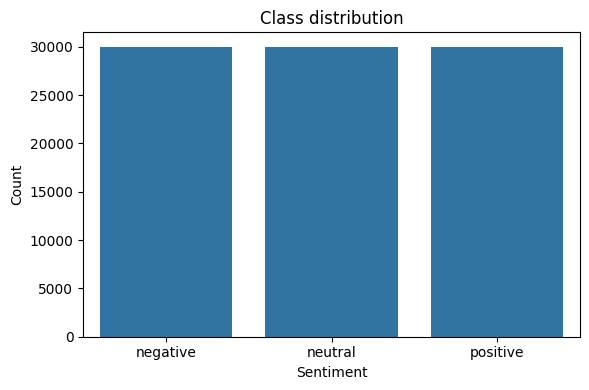

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment", order=["negative", "neutral", "positive"])
plt.title("Class distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_distribution.png", dpi=200)
plt.show()

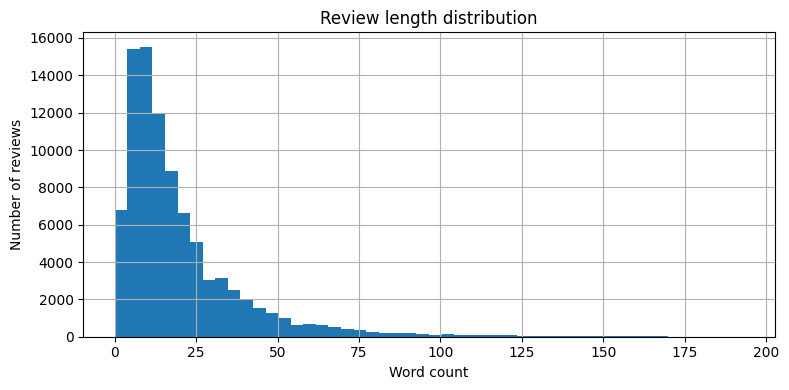

In [7]:
plt.figure(figsize=(8, 4))
df["word_count"].hist(bins=50)
plt.title("Review length distribution")
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "review_length_distribution.png", dpi=200)
plt.show()

## Очистка и сохранение processed dataset

In [8]:
def clean_text(text: str) -> str:
    """
    Basic text preprocessing for Russian review sentiment classification.
    """
    if text is None:
        return ""

    text = str(text).lower()
    text = text.replace("ё", "е")
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^а-яa-z0-9\s!?.,-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


prepared_df = df[["review", "sentiment"]].copy()
prepared_df = prepared_df.rename(columns={"review": "text"})

prepared_df["text"] = prepared_df["text"].apply(clean_text)

prepared_df = prepared_df.dropna(subset=["text", "sentiment"])
prepared_df = prepared_df[prepared_df["text"].str.len() > 0]
prepared_df = prepared_df.drop_duplicates(subset=["text"])
prepared_df = prepared_df.reset_index(drop=True)

prepared_summary = pd.DataFrame({
    "Показатель": [
        "Строк до обработки",
        "Строк после обработки",
        "Удалено строк",
        "Количество классов"
    ],
    "Значение": [
        df.shape[0],
        prepared_df.shape[0],
        df.shape[0] - prepared_df.shape[0],
        prepared_df["sentiment"].nunique()
    ]
})

prepared_df.to_csv(PROCESSED_DATA_PATH, index=False)

display(prepared_summary)
display(prepared_df.head())
display(prepared_df["sentiment"].value_counts().rename_axis("sentiment").reset_index(name="count"))

,Показатель,Значение
0,Строк до обработки,90000
1,Строк после обработки,86146
2,Удалено строк,3854
3,Количество классов,3


,text,sentiment
0,качество плохое пошив ужасный горловина напере...,negative
1,"товар отдали другому человеку, я не получила п...",negative
2,"ужасная синтетика! тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"кофточка голая синтетика, носить не возможно.",negative


,sentiment,count
0,positive,28956
1,negative,28817
2,neutral,28373


## Сохранение краткого EDA summary

In [9]:
eda_summary = f"""
# EDA Summary

## Dataset

В проекте используется датасет RuReviews: русскоязычные отзывы о женской одежде и аксессуарах.

## Raw dataset

- Rows: {raw_shape[0]}
- Columns: {raw_shape[1]}
- Text column: review
- Target column: sentiment

## Prepared dataset

- Rows after preprocessing: {prepared_df.shape[0]}
- Columns after preprocessing: {prepared_df.shape[1]}

## Class distribution after preprocessing

{prepared_df["sentiment"].value_counts().to_string()}

## Preprocessing steps

- Исправлена метка `neautral` на `neutral`.
- Текст приведён к нижнему регистру.
- Символ `ё` заменён на `е`.
- Удалены ссылки.
- Удалены лишние символы.
- Удалены пустые строки.
- Удалены дубликаты по тексту отзыва.

## Main observations

1. Исходный датасет сбалансирован по трём классам.
2. В датасете есть три класса: negative, neutral, positive.
3. В исходных метках была опечатка `neautral`, она исправлена.
4. Отзывы имеют разную длину: есть короткие и более длинные тексты.
5. Датасет подходит для обучения baseline-моделей на основе TF-IDF.

## Risks and limitations

1. Датасет относится к конкретной товарной категории: одежда и аксессуары.
2. Модель может хуже работать на отзывах из других доменов.
3. Возможны ошибки в автоматической разметке.
4. Короткие отзывы могут быть неоднозначными для классификации.
"""

summary_path = REPORTS_DIR / "eda_summary.md"
summary_path.write_text(eda_summary, encoding="utf-8")

summary_path

WindowsPath('../reports/eda_summary.md')

## Выводы

Датасет подходит для задачи классификации тональности отзывов. Он сбалансирован по трём классам, не содержит пропусков в ключевых колонках, но содержит дубликаты по тексту отзывов. После базовой очистки и удаления дубликатов подготовлена processed-версия датасета, которая будет использоваться для обучения baseline-моделей.